In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cvx
from google.colab import files

In [34]:
uploaded = files.upload()

data = pd.read_csv('Table.csv')

print(data.head())

Saving Table.csv2.xlsx to Table.csv2.xlsx
   Hour  Solar  Load  Price
0     0      0  68.5    140
1     1      0  69.5    140
2     2      0  68.0    140
3     3      0  64.5    140
4     4      0  64.5    140


In [35]:
T = 24

p_stor = cvx.Variable(T)
p_grid = cvx.Variable(T)
e_stor = cvx.Variable(T+1)

pmax = 30
emax = 150

objective = 0

constraints = [
    p_stor >= -pmax,
    p_stor <= pmax,
    e_stor >= 0,
    e_stor <= emax,
    e_stor[0] == 100
]

for t in range(T):

    objective += data["Price"][t] * p_grid[t]

    constraints += [
        e_stor[t+1] == e_stor[t] + p_stor[t]
    ]

    constraints += [
        p_grid[t] + data["Solar"][t] == p_stor[t] + data["Load"][t]
    ]

problem = cvx.Problem(cvx.Minimize(objective), constraints)

problem.solve()

print("Status:", problem.status)
print("Optimal objective value:", problem.value)

Status: optimal
Optimal objective value: 336252.00002503296


In [36]:
results = pd.DataFrame({
    "Hour": np.arange(T),
    "Solar (kW)": data["Solar"].values[:T],
    "Load (kW)": data["Load"].values[:T],
    "Price": data["Price"].values[:T],
    "Battery Power (kW)": p_stor.value,
    "Grid Power (kW)": p_grid.value,
    "Battery Energy Start (kWh)": e_stor.value[:-1],
    "Battery Energy End (kWh)": e_stor.value[1:]
})

results

,Hour,Solar (kW),Load (kW),Price,Battery Power (kW),Grid Power (kW),Battery Energy Start (kWh),Battery Energy End (kWh)
0,0,0,68.5,140,-6.618384e+00,61.881616,1.000000e+02,9.338162e+01
1,1,0,69.5,140,4.512490e+00,74.012490,9.338162e+01,9.789411e+01
2,2,0,68.0,140,1.154266e+01,79.542658,9.789411e+01,1.094368e+02
3,3,0,64.5,140,1.752221e+01,82.022207,1.094368e+02,1.269590e+02
4,4,0,64.5,140,2.304103e+01,87.541029,1.269590e+02,1.500000e+02
5,5,0,70.5,175,-1.974509e+01,50.754910,1.500000e+02,1.302549e+02
6,6,0,82.5,210,-3.000000e+01,52.500000,1.302549e+02,1.002549e+02
7,7,26,100.0,210,-3.000000e+01,44.000000,1.002549e+02,7.025491e+01
8,8,50,112.0,210,-3.000000e+01,32.000000,7.025491e+01,4.025491e+01
9,9,71,112.0,175,8.744213e-01,41.874421,4.025491e+01,4.112933e+01


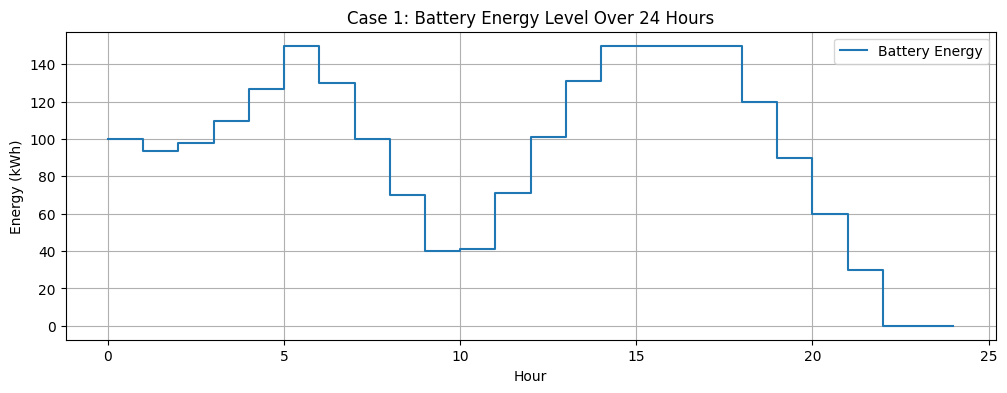

In [37]:
plt.figure(figsize=(12,4))

plt.step(np.arange(T+1), e_stor.value, where="post", label="Battery Energy")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Case 1: Battery Energy Level Over 24 Hours")
plt.grid(True)
plt.legend()
plt.show()